In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

data = {
    'OrderID':           range(1001, 1001 + n),
    'Region':            np.random.choice(['North', 'South', 'East', 'West'], n),
    'Product':           np.random.choice(['Electronics', 'Clothing', 'Food', 'Furniture'], n),
    'Quantity':          np.random.randint(1, 20, n),
    'UnitPrice':         np.random.randint(100, 5000, n),
    'Discount':          np.random.choice([0, 5, 10, 15, 20], n),
    'AdvertisingSpend':  np.random.randint(500, 10000, n),
    'CustomerAge':       np.random.randint(18, 65, n),
}

df = pd.DataFrame(data)
df['Sales'] = (df['Quantity'] * df['UnitPrice']) * (1 - df['Discount'] / 100)
df['Sales'] = df['Sales'].round(2)

import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/sales_data.csv', index=False)

print("Dataset saved ✅")
print(f"Shape: {df.shape}")
df.head()

Dataset saved ✅
Shape: (1000, 9)


,OrderID,Region,Product,Quantity,UnitPrice,Discount,AdvertisingSpend,CustomerAge,Sales
0,1001,East,Clothing,15,2296,5,9066,54,32718.0
1,1002,West,Food,12,3847,10,7726,29,41547.6
2,1003,North,Electronics,16,751,0,5662,47,12016.0
3,1004,East,Electronics,19,869,10,706,44,14859.9
4,1005,East,Electronics,8,2521,0,5375,56,20168.0


In [2]:
df = pd.read_csv('../data/sales_data.csv')
print("Dataset loaded ✅")

Dataset loaded ✅


In [3]:
df.head()

,OrderID,Region,Product,Quantity,UnitPrice,Discount,AdvertisingSpend,CustomerAge,Sales
0,1001,East,Clothing,15,2296,5,9066,54,32718.0
1,1002,West,Food,12,3847,10,7726,29,41547.6
2,1003,North,Electronics,16,751,0,5662,47,12016.0
3,1004,East,Electronics,19,869,10,706,44,14859.9
4,1005,East,Electronics,8,2521,0,5375,56,20168.0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 9


In [5]:
print(df.columns.tolist())


['OrderID', 'Region', 'Product', 'Quantity', 'UnitPrice', 'Discount', 'AdvertisingSpend', 'CustomerAge', 'Sales']


In [6]:
print(df.dtypes)

OrderID               int64
Region                  str
Product                 str
Quantity              int64
UnitPrice             int64
Discount              int64
AdvertisingSpend      int64
CustomerAge           int64
Sales               float64
dtype: object


In [7]:
print(df.isnull().sum())

OrderID             0
Region              0
Product             0
Quantity            0
UnitPrice           0
Discount            0
AdvertisingSpend    0
CustomerAge         0
Sales               0
dtype: int64


In [8]:
df.describe()


,OrderID,Quantity,UnitPrice,Discount,AdvertisingSpend,CustomerAge,Sales
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,9.926000,2514.580000,9.905000,5268.979000,40.946000,22553.234250
std,288.819436,5.446484,1366.928205,7.086338,2774.126346,13.348456,18686.458973
min,1001.000000,1.000000,106.000000,0.000000,511.000000,18.000000,190.400000
25%,1250.750000,5.000000,1356.750000,5.000000,2821.000000,30.000000,7516.700000
50%,1500.500000,10.000000,2424.000000,10.000000,5199.500000,40.000000,17070.200000
75%,1750.250000,15.000000,3734.750000,15.000000,7707.250000,52.000000,33070.750000
max,2000.000000,19.000000,4997.000000,20.000000,9999.000000,64.000000,86260.950000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/sales_data_cleaned.csv')
print("Loaded ✅ Shape:", df.shape)

Loaded ✅ Shape: (1000, 14)


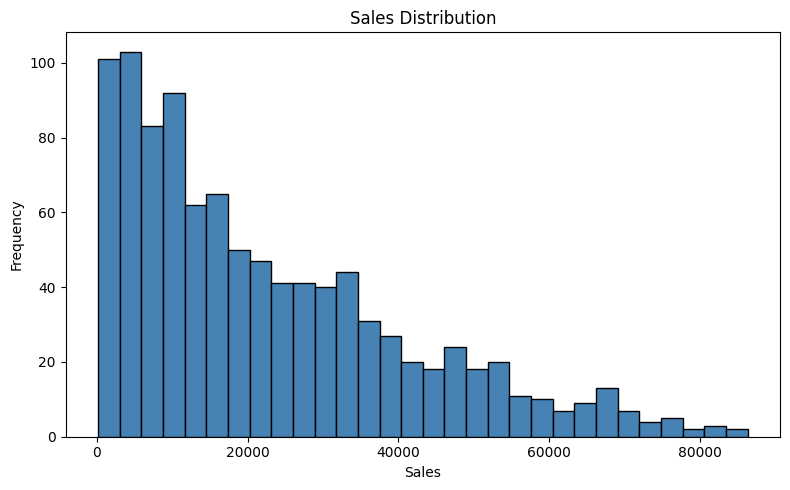

Chart saved ✅


In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=30, color='steelblue', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../data/sales_distribution.png')
plt.show()
print("Chart saved ✅")

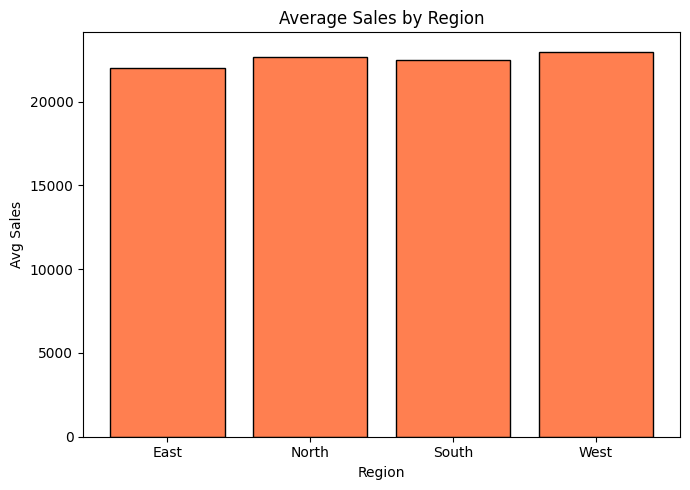

Chart saved ✅


In [3]:
region_cols = ['Region_East', 'Region_North', 'Region_South', 'Region_West']
avg_sales = {col.replace('Region_', ''): df[df[col] == True]['Sales'].mean() for col in region_cols}

plt.figure(figsize=(7, 5))
plt.bar(avg_sales.keys(), avg_sales.values(), color='coral', edgecolor='black')
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('../data/sales_by_region.png')
plt.show()
print("Chart saved ✅")

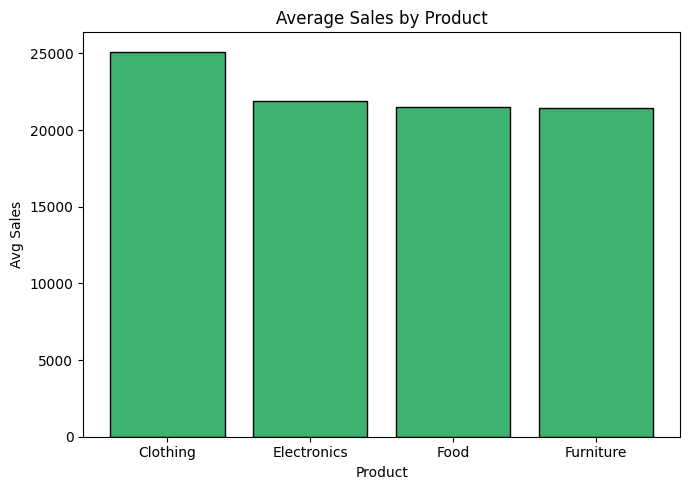

Chart saved ✅


In [4]:
product_cols = ['Product_Clothing', 'Product_Electronics', 'Product_Food', 'Product_Furniture']
avg_sales_p = {col.replace('Product_', ''): df[df[col] == True]['Sales'].mean() for col in product_cols}

plt.figure(figsize=(7, 5))
plt.bar(avg_sales_p.keys(), avg_sales_p.values(), color='mediumseagreen', edgecolor='black')
plt.title('Average Sales by Product')
plt.xlabel('Product')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('../data/sales_by_product.png')
plt.show()
print("Chart saved ✅")

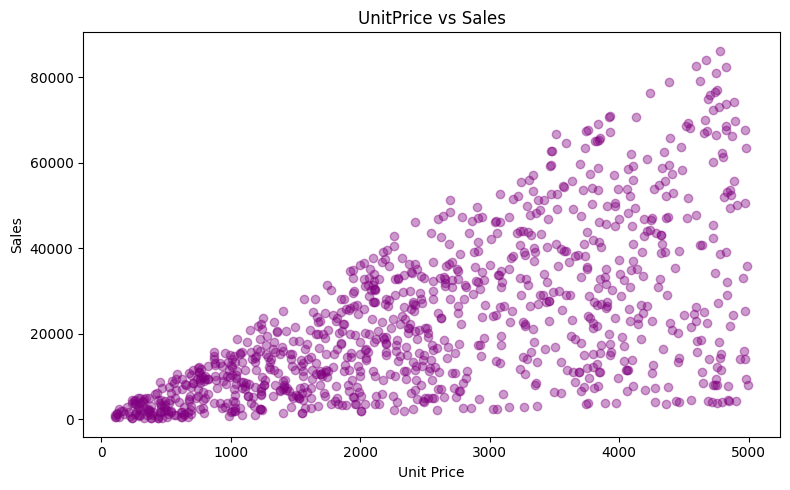

Chart saved ✅


In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df['UnitPrice'], df['Sales'], alpha=0.4, color='purple')
plt.title('UnitPrice vs Sales')
plt.xlabel('Unit Price')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../data/unitprice_vs_sales.png')
plt.show()
print("Chart saved ✅")

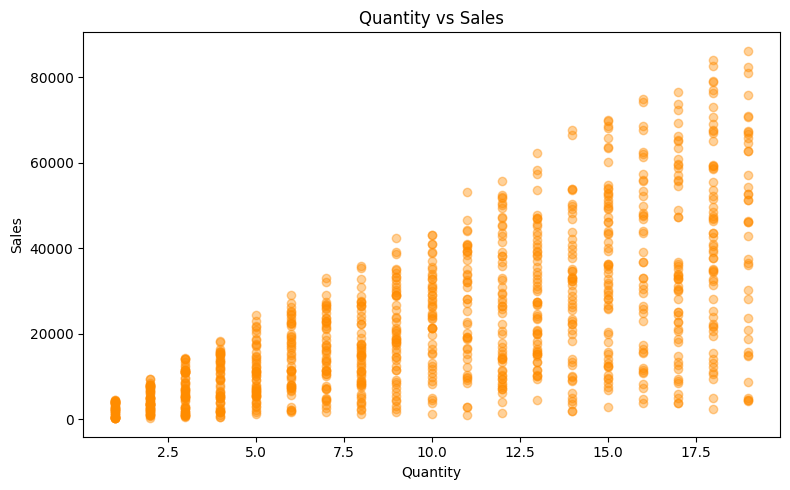

Chart saved ✅


In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['Sales'], alpha=0.4, color='darkorange')
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../data/quantity_vs_sales.png')
plt.show()
print("Chart saved ✅")

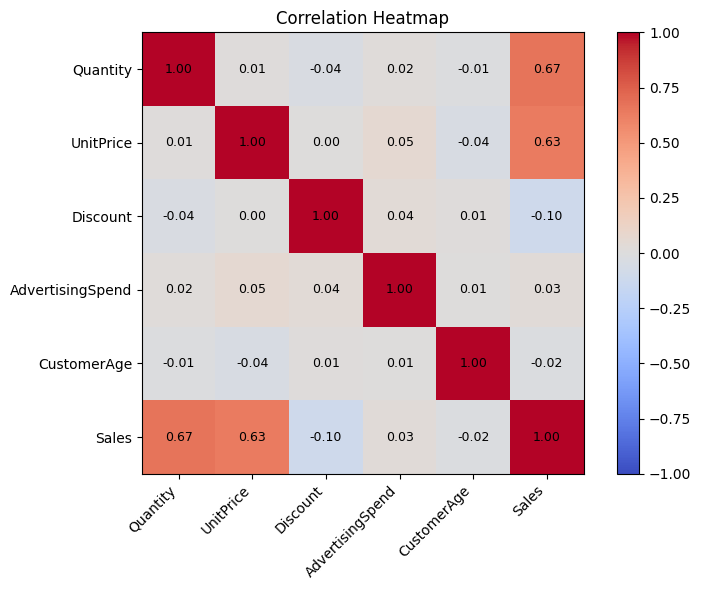

Chart saved ✅


In [7]:
num_cols = ['Quantity', 'UnitPrice', 'Discount', 'AdvertisingSpend', 'CustomerAge', 'Sales']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()
print("Chart saved ✅")